# RPS tracking

This notebook shows the full RPS-tracking loop: pull a recording span, examine it, run a neural predictor from the zoo, and run the blind DSP tracking ladder on the same audio. Each step is one or two calls into the library (`plots.explore`, `plots.dwym`, `zoo`, `tracking`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (ROOT, ROOT / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import tdseries as td
import matplotlib.pyplot as plt

from plots import dwym, explore

## 1 · Datasets

`explore.datasets()` lists every published dataset pinned in `dload.lock`. Pass `sizes=True` for sample counts (fetches manifests).

In [2]:
explore.datasets()

,name,version
0,AVQ,50dd53d1a6c0
1,AVQ-egonoise,b43b374b007a
2,AVQ-egonoise-vkrps,266f5241bfb0
3,AVQ-raw,0e17e52b16c3
4,AeroSonicDB,0d5543419ea5
5,DN-LM-train,4576c1679b3b
6,DN-LM-valid,f6e7038600b9
7,DREGON,db39bcf762d0
8,DREGON-LM-V2-train,8a81bf7b7b5d
9,DREGON-LM-V2-valid,1eb8384871be


## 2 · Pull a recording span

The data cells stream from R2. This guard fails early, with a clear message, when credentials are missing.

In [3]:
import os

import data_processing.streams  # noqa: F401 — loads the .env credentials

if not os.environ.get("AWS_ACCESS_KEY_ID"):
    raise RuntimeError(
        "No R2 credentials. The cells below stream dload datasets. "
        "Fill .env at the repo root (see docs/data-and-artifacts.md), then rerun."
    )

In [4]:
rec = explore.pick("DREGON-frames", "free-flight_nosource_room1")
rec = rec.shift(-rec.t_start)

/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/src/plots/explore.py:131: UserWarning: coerce_frame: using entry 'motors_measured' as 'rps' — pass rps='motors_measured' to make the mapping explicit
  return coerce_frame(frame, **present)


In [5]:
rec.keys()

dict_keys(['audio', 'rps', 'motors_command', 'imu_accel', 'imu_gyro', 'mic_pos', 'rotor_pos', 'meta', 'motors_command_raw', 'audio_timestamps'])

In [10]:
clip = rec.time[20.0:28.0].shift(-20.0)  # 8 s of stable flight, re-based to t=0
clip["audio"].tindex

GridIndex(sr_num=44100, size=352800, sr_den=1, t_start_ticks=0, dur_ticks=8000000000, phase=0.0)

`dwym` selects the figure from the entry names: here spectrogram + RPS rows + an audio player. `explore.pick` already coerced the raw entry names (`motors_command` → `rps`).

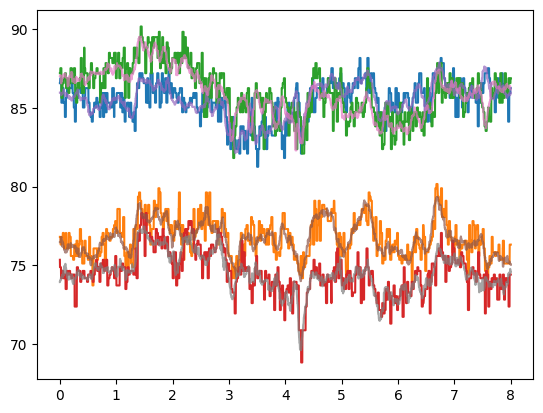

In [18]:
plt.plot(clip['rps'].timestamps, clip['rps'].data.T, ls='-')
plt.plot(clip['motors_command'].timestamps, clip['motors_command'].data.T, ls='-', alpha=0.7)

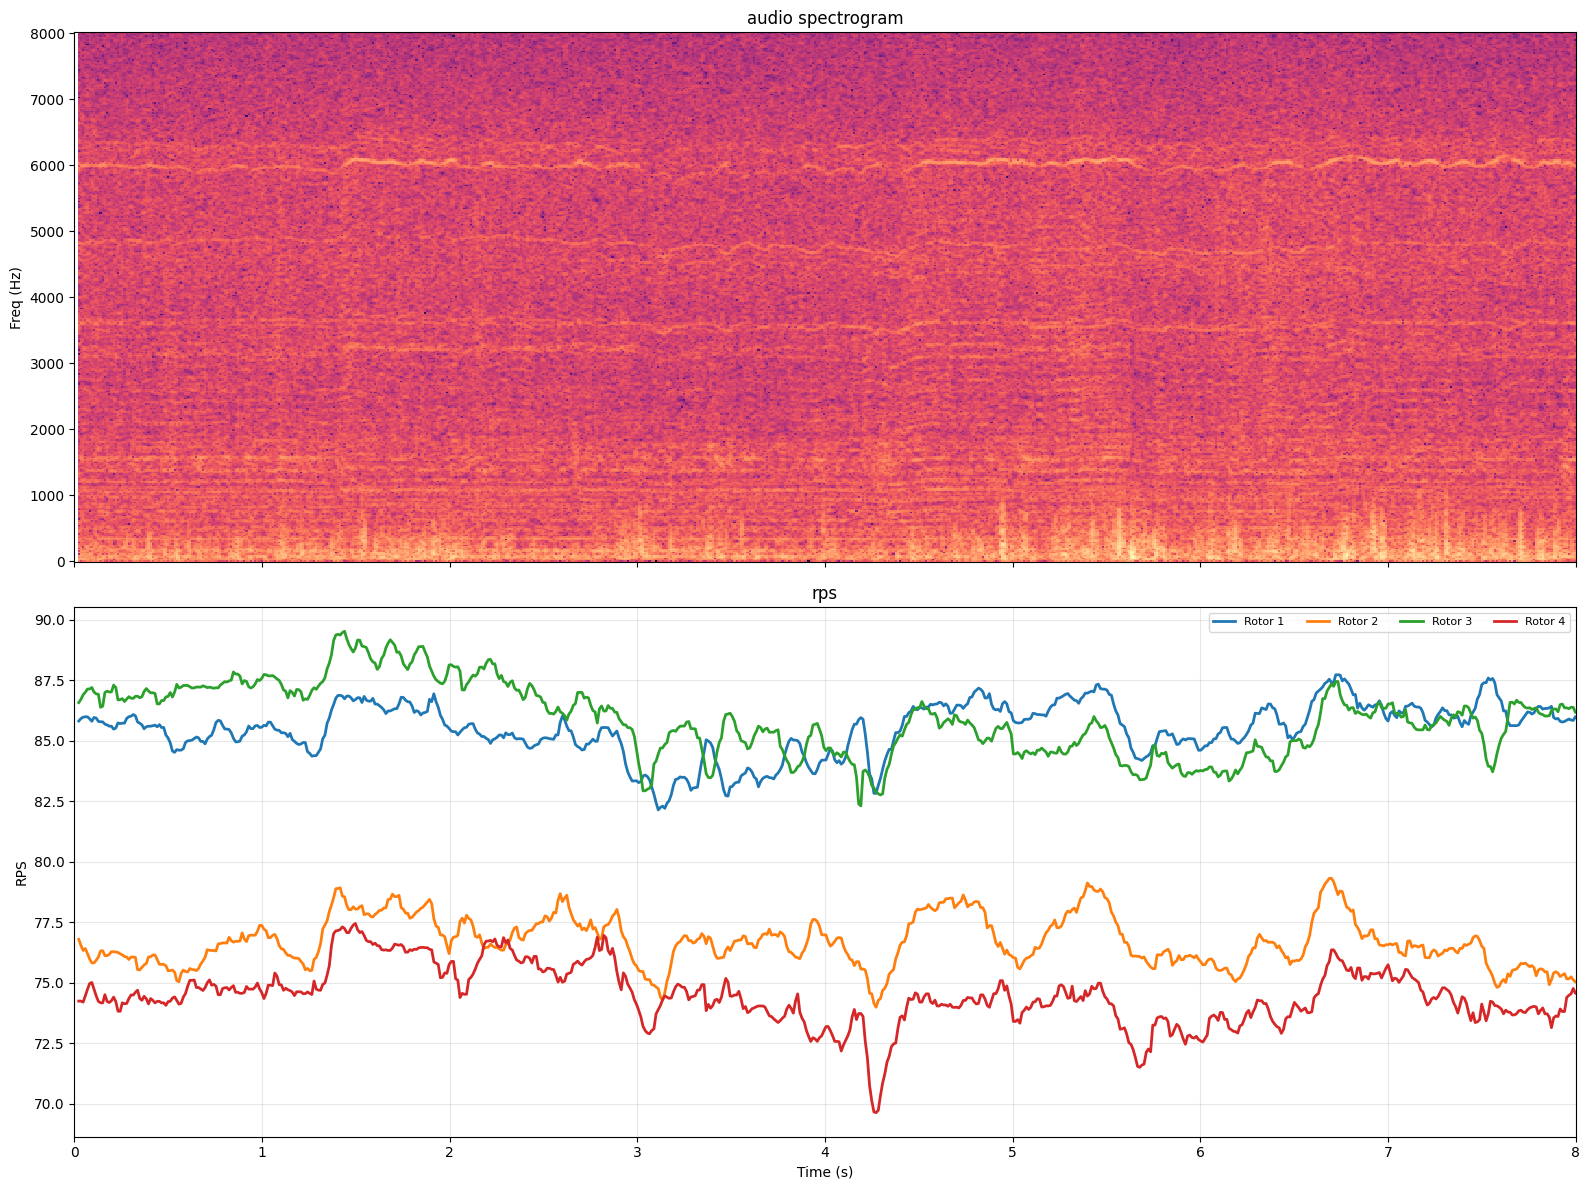

audio


In [19]:
dwym(clip, fmax=8000)

## 3 · A neural predictor from the zoo

`zoo.checkpoints` lists trained experiments from the R2 artifact store (cached locally). `zoo.load` returns the model as one Frame → Frame callable.

In [36]:
import zoo

In [37]:
ckla_ckpts = sorted([c for c in zoo.checkpoints('rps_prediction') if c['experiment'].startswith('ckla')],
                     key=lambda c: max(c['mtimes']))
ckla_ckpts.reverse()
ckla_ckpts

[{'experiment': 'ckla_phaseonly_8s_ft',
  'task': 'rps_prediction',
  'files': ['best.ckpt', 'last.ckpt'],
  'sizes': [7421362, 7421362],
  'mtimes': ['2026-07-30T17:21:18.425000+00:00',
   '2026-07-30T20:11:19.779000+00:00'],
  'has_config': True,
  'metrics': None},
 {'experiment': 'ckla_phaseonly_8s',
  'task': 'rps_prediction',
  'files': ['best.ckpt', 'last.ckpt'],
  'sizes': [7421362, 7421362],
  'mtimes': ['2026-07-29T14:40:22.896000+00:00',
   '2026-07-30T08:31:33.191000+00:00'],
  'has_config': True,
  'metrics': None},
 {'experiment': 'ckla_phaseonly_4s',
  'task': 'rps_prediction',
  'files': ['best.ckpt', 'last.ckpt'],
  'sizes': [7421362, 7421362],
  'mtimes': ['2026-07-29T04:59:10.731000+00:00',
   '2026-07-29T12:18:43.839000+00:00'],
  'has_config': True,
  'metrics': None},
 {'experiment': 'ckla_refiner',
  'task': 'rps_prediction',
  'files': ['best.ckpt', 'last.ckpt'],
  'sizes': [7443678, 7443678],
  'mtimes': ['2026-07-29T05:23:43.050000+00:00',
   '2026-07-29T06:11

In [39]:
nonckla_ckpts = list(
    reversed(sorted([c for c in zoo.checkpoints('rps_prediction') if not c['experiment'].startswith('ckla')],
                     key=lambda c: max(c['mtimes'])))
)

nonckla_ckpts

[{'experiment': 'unigru128_fs_v2',
  'task': 'rps_prediction',
  'files': ['best.ckpt', 'last.ckpt'],
  'sizes': [6501373, 6501373],
  'mtimes': ['2026-07-29T10:30:30.433000+00:00',
   '2026-07-29T11:04:38.555000+00:00'],
  'has_config': True,
  'metrics': None},
 {'experiment': 'scv2_fs_v2',
  'task': 'rps_prediction',
  'files': ['best.ckpt', 'last.ckpt'],
  'sizes': [6043325, 6043325],
  'mtimes': ['2026-07-29T10:17:44.881000+00:00',
   '2026-07-29T10:44:34.873000+00:00'],
  'has_config': True,
  'metrics': None},
 {'experiment': 'fkla_fs_v2',
  'task': 'rps_prediction',
  'files': ['best.ckpt', 'last.ckpt'],
  'sizes': [7142032, 7142032],
  'mtimes': ['2026-07-28T02:12:24.065000+00:00',
   '2026-07-28T02:40:16.231000+00:00'],
  'has_config': True,
  'metrics': None},
 {'experiment': 'g2_if_v3synth',
  'task': 'rps_prediction',
  'files': ['best.ckpt', 'last.ckpt'],
  'sizes': [5963311, 5963311],
  'mtimes': ['2026-07-27T21:59:53.096000+00:00',
   '2026-07-27T22:06:04.807000+00:00']

In [44]:
from data_processing.frames import resample_audio_series
from utils.audio import first_channel

audio16 = resample_audio_series(first_channel(clip["audio"]), 16000)

predictor_ids = [
    'ckla_phaseonly_8s_ft',
    'ckla_phaseonly_8s',
    'ckla_phaseonly_4s',
    # 'ckla_refiner',
]

predictors = {pid: zoo.load(pid) for pid in predictor_ids}
preds = {pid: predictor(td.Frame({"mixture": audio16})) for pid, predictor in predictors.items()}
overlays = {
    pid: td.Frame({"audio": audio16, "rps": clip["rps"], "rps_pred": pred["rps_pred"]})
    for pid, pred in preds.items()
}

Overlay the prediction on the telemetry. `dwym` PIT-aligns `rps_pred` to `rps` before it draws.

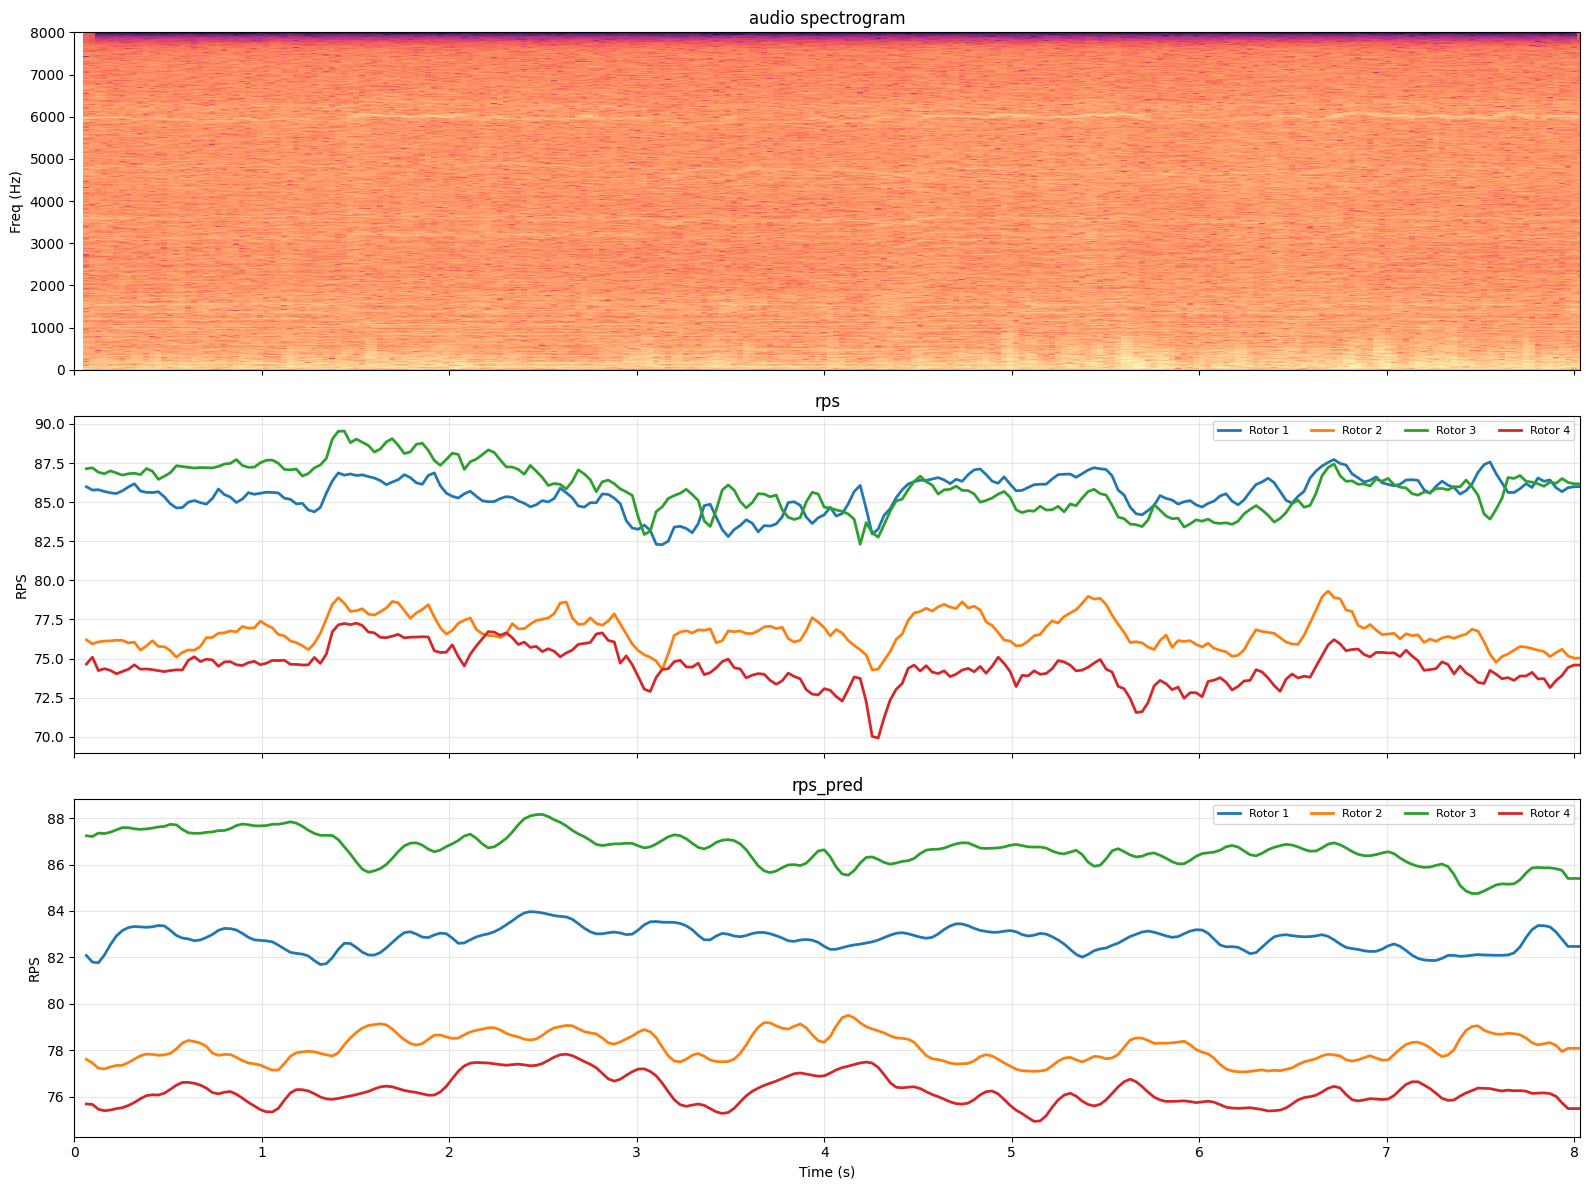

audio


In [50]:
dwym(overlays['ckla_phaseonly_4s'], fmax=8000)

## 4 · The blind DSP tracking ladder

Tracking stages are `td.Frame → td.Frame` callables (`tracking.stages`). `blind_seed_stage` finds the base speeds; the guarded VK stage captures and refines the trajectories. For the full calibrated annotation ladder, use `tracking.vit2dsp_stage`.

In [51]:
import tracking as trk

tf = td.Frame({"audio": audio16, "rps_meas": clip["rps"], "meta": td.Frame({})})
ladder = trk.pipeline(trk.blind_seed_stage(4), trk.guarded(trk.vk_stage(trk.CAPTURE_CFG)))
tracked = ladder(tf)  # roughly a minute on CPU for 8 s of audio

Overlay the tracked trajectories on the telemetry the same way.

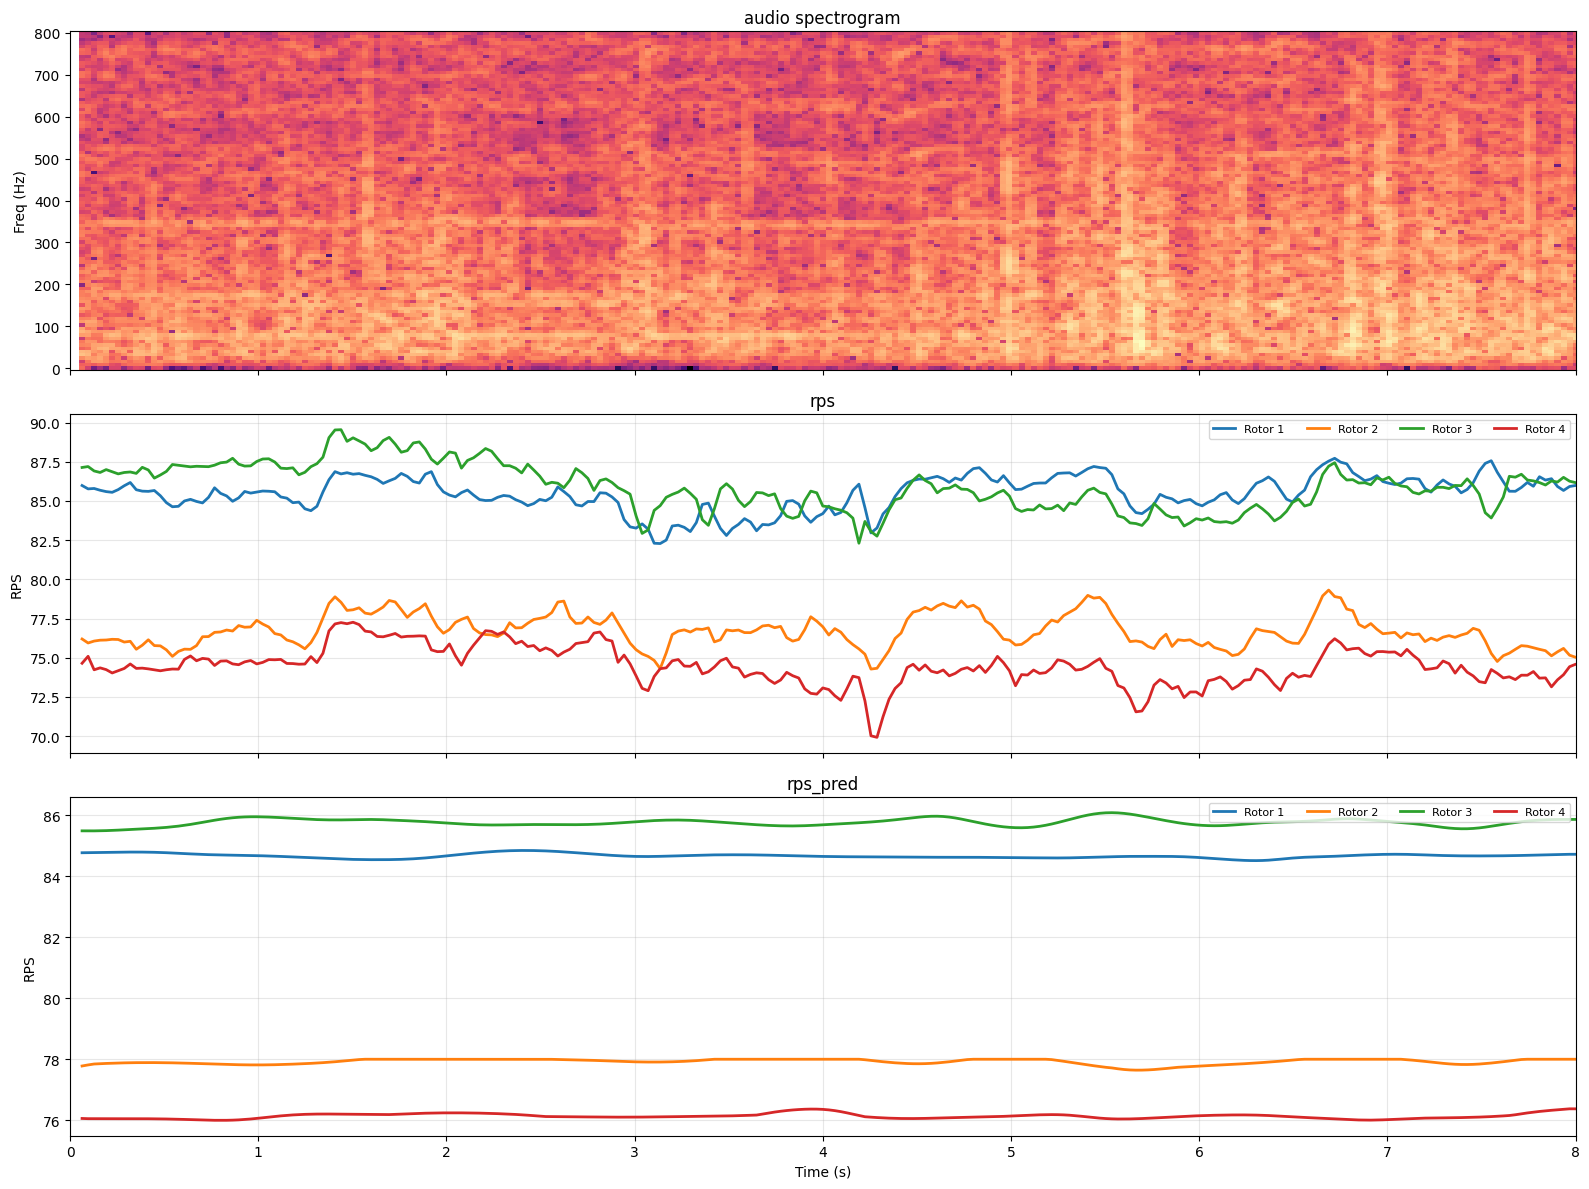

audio


In [52]:
overlay = td.Frame({"audio": audio16, "rps": clip["rps"], "rps_pred": tracked["rps"]})
dwym(overlay, fmax=800)

## 5 · The tracking log

Every stage appends one diagnostics dict to `meta["tracking"]`.

In [ ]:
for entry in tracked["meta"]["tracking"]:
    info = {k: v for k, v in entry.items() if k != "stage"}
    print(f"{entry['stage']:12s} {info}")

Next steps: `docs/notebook-primitives-tutorial.md` walks each primitive, `src/tracking/AGENTS.md` documents the stage API, and `notebooks/AGENTS.md` maps the other notebooks.